QUESTION 1
Consider the following three variables for 20 different basketball players: points, assists, and rebounds.
Perform k-means clustering manually with K=2, using Euclidean distance. Show the working for one iteration
in your Lab Observation Book by using Euclidean distance.
Write a Python function (without using the scikit-learn library) to create a DataFrame containing the three
variables (points, assists, and rebounds) for 20 different basketball players.
Apply the K-means algorithm to identify clusters with K=1, 2, K=3, and K=4, using distance formulas such as
Euclidean distance, Manhattan distance, and Minkowski distance. Perform the following tasks:
a. Create a scatter plot of the data points in blue.
b. Plot the clusters with data points in different colors for K=1, 2, 3, and 4 in separate graphs.
c. Create a plot showing the number of clusters on the x-axis and the Sum of Squared Errors (SSE) on the y-axis.
Compute SSE for all iterations. Show the table of given data points against SSE for every iteration and use the
total sum of SSE in the graph of K vs. SSE .
d. Show the optimal value of K using the Elbow method and mark the same in the graph.
if k=1 then choose the mean of the points as the cluster centers
if k =2 then choose first 2 points as the cluster centers
if k =3 then choose first 3 points as the cluster centers
if k =4 then choose first 4 points as the cluster centers

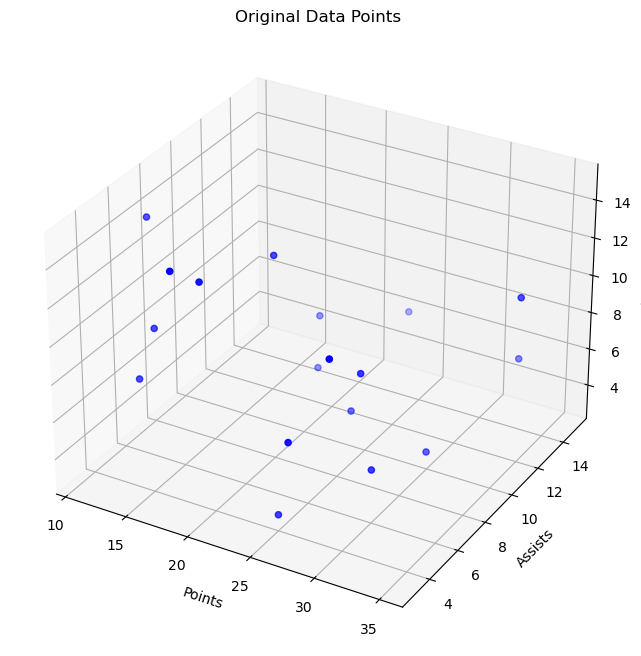

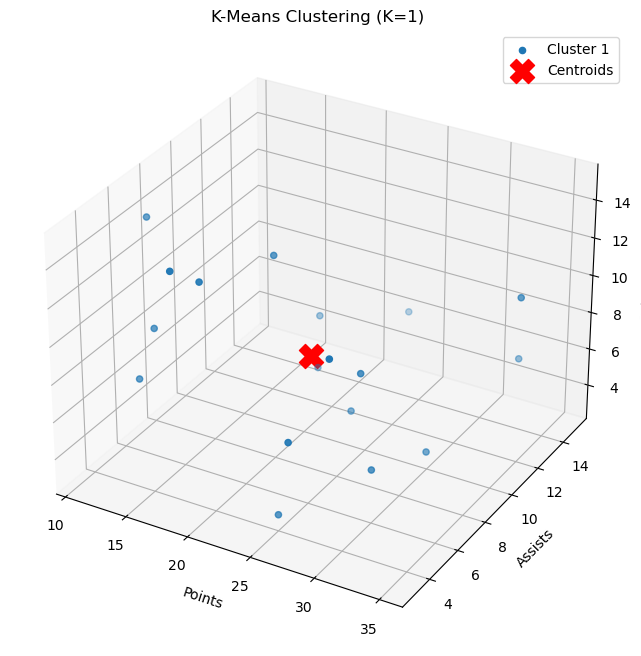

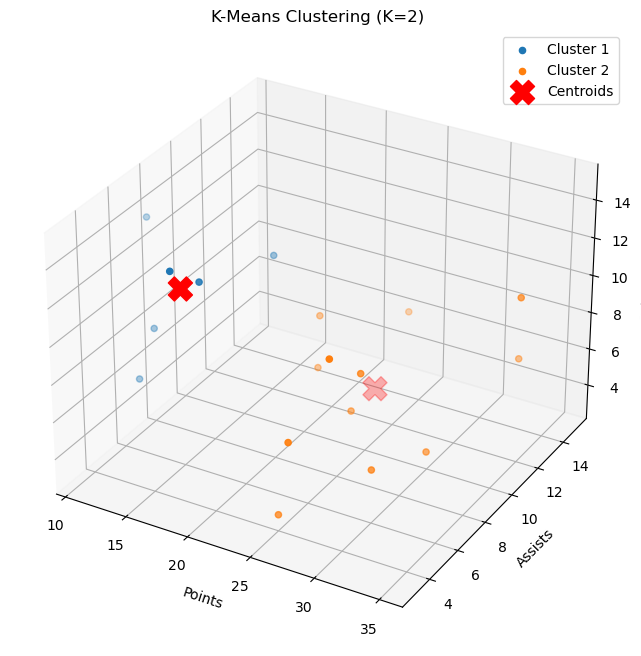

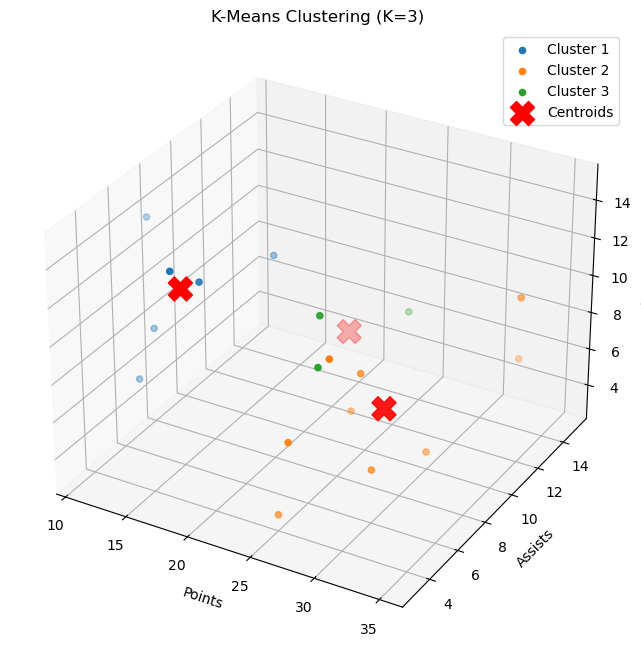

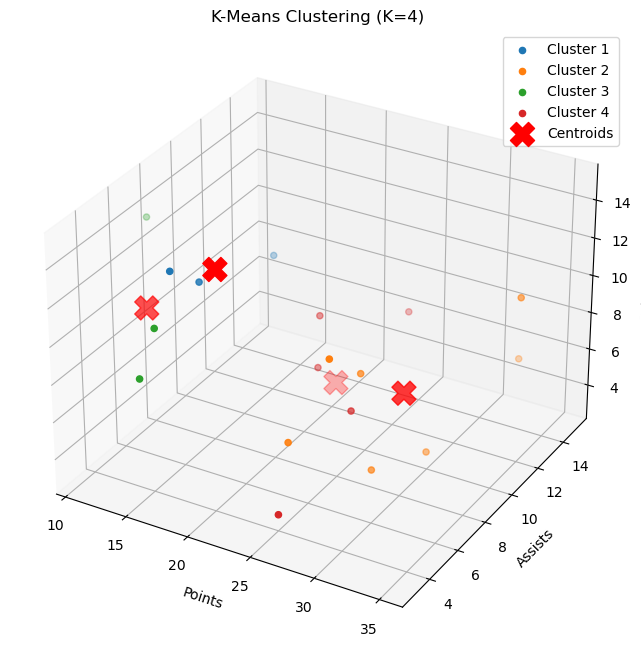

SSE for each K:
K=1, SSE=1320.8333333333333
K=2, SSE=651.0
K=3, SSE=425.27777777777777
K=4, SSE=355.56190476190477


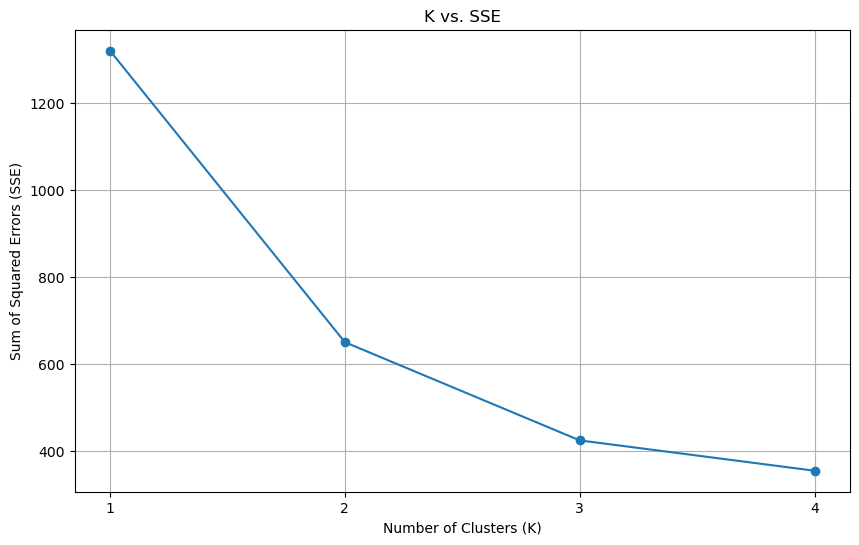

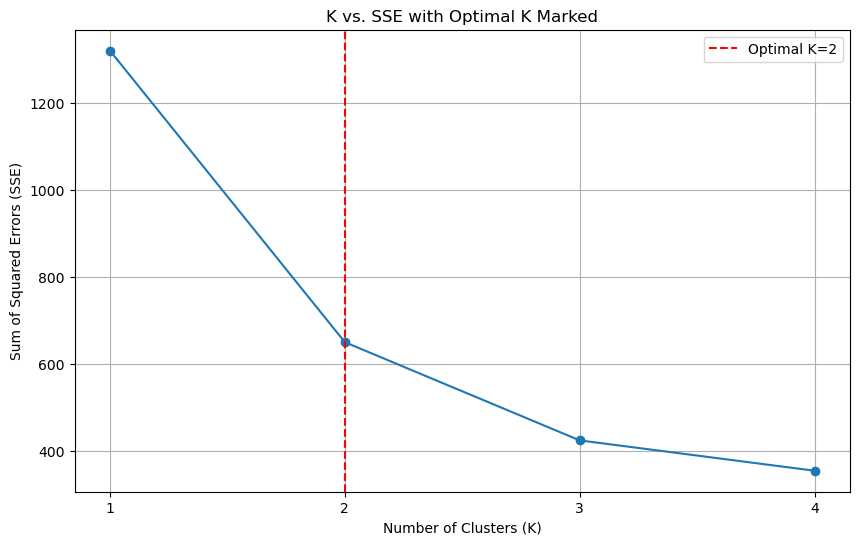

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Step 1: Create the DataFrame
data = {
    'points': [18.0, 19.0, 14.0, 14.0, 11.0, 20.0, 28.0, 30.0, 31.0, 35.0,
               33.0, 25.0, 25.0, 27.0, 29.0, 19.0, 23.0, 20.0],
    'assists': [3.0, 4.0, 5.0, 4.0, 7.0, 8.0, 7.0, 6.0, 9.0, 12.0,
                14.0, 9.0, 4.0, 3.0, 4.0, 12.0, 15.0, 11.0],
    'rebounds': [15, 14, 10, 8, 14, 13, 9, 5, 4, 11,
                 6, 5, 3, 8, 12, 7, 6, 5]
}

# Create a DataFrame
df = pd.DataFrame(data)

# Convert DataFrame to NumPy array
data_array = df.to_numpy()

# Step 2: K-means Clustering using Euclidean Distance
def euclidean_distance(a, b):
    return np.linalg.norm(a - b)

def k_means_clustering(data, k, iterations=10):
    # Step 1: Initialize centroids
    if k == 1:
        centroids = np.mean(data, axis=0).reshape(1, -1)
    else:
        centroids = data[:k]

    for _ in range(iterations):
        # Step 2: Assign clusters
        distances = np.array([[euclidean_distance(point, centroid) for centroid in centroids] for point in data])
        clusters = np.argmin(distances, axis=1)

        # Step 3: Update centroids
        new_centroids = np.array([data[clusters == i].mean(axis=0) for i in range(k)])

        # Check for convergence (if centroids don't change)
        if np.all(centroids == new_centroids):
            break

        centroids = new_centroids

    return clusters, centroids

# Step 3: Visualizing the Data
def plot_data(data):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(data[:, 0], data[:, 1], data[:, 2], c='blue', marker='o')
    ax.set_title('Original Data Points')
    ax.set_xlabel('Points')
    ax.set_ylabel('Assists')
    ax.set_zlabel('Rebounds')
    plt.show()

def plot_clusters(data, clusters, centroids, k, title):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    for i in range(k):
        ax.scatter(data[clusters == i, 0], data[clusters == i, 1], data[clusters == i, 2], label=f'Cluster {i+1}')
    ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2], s=300, c='red', label='Centroids', marker='X')
    ax.set_title(title)
    ax.set_xlabel('Points')
    ax.set_ylabel('Assists')
    ax.set_zlabel('Rebounds')
    ax.legend()
    plt.show()

# Plot original data
plot_data(data_array)

# Step 4: Run K-means for Different Values of K and Calculate SSE
k_values = [1, 2, 3, 4]
sse_list = []

# Perform clustering for each K
for k in k_values:
    clusters, centroids = k_means_clustering(data_array, k)
    # Calculate SSE
    sse = np.sum([euclidean_distance(data_array[i], centroids[clusters[i]]) ** 2 for i in range(len(data_array))])
    sse_list.append(sse)
    plot_clusters(data_array, clusters, centroids, k, f'K-Means Clustering (K={k})')

# Display SSE results
print("SSE for each K:")
for k, sse in zip(k_values, sse_list):
    print(f'K={k}, SSE={sse}')

# Step 5: Plotting K vs. SSE
plt.figure(figsize=(10, 6))
plt.plot(k_values, sse_list, marker='o')
plt.title('K vs. SSE')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.xticks(k_values)
plt.grid(True)
plt.show()

# Step 6: Determine the Optimal Value of K Using the Elbow Method
optimal_k = 2  # This is an example; determine it based on your SSE graph
plt.figure(figsize=(10, 6))
plt.plot(k_values, sse_list, marker='o')
plt.axvline(x=optimal_k, color='r', linestyle='--', label=f'Optimal K={optimal_k}')
plt.title('K vs. SSE with Optimal K Marked')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.xticks(k_values)
plt.grid(True)
plt.legend()
plt.show()

QUESTION 2.Redo 1(a)-1(d) using Manhattan distance.

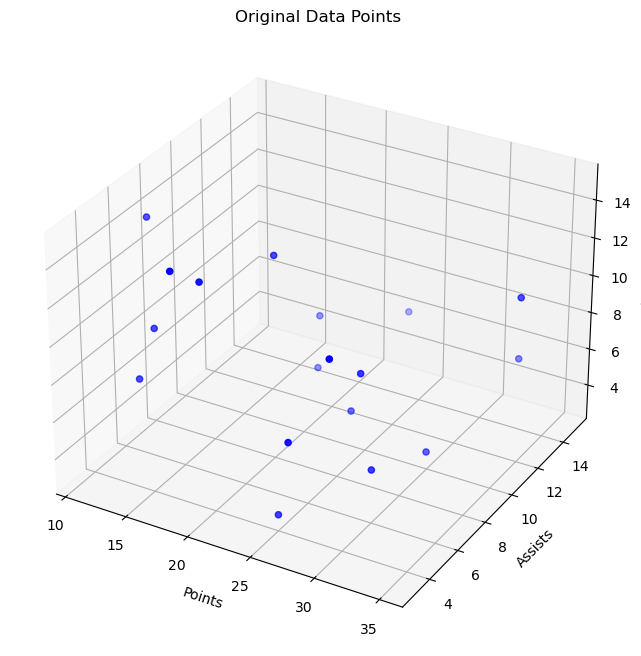

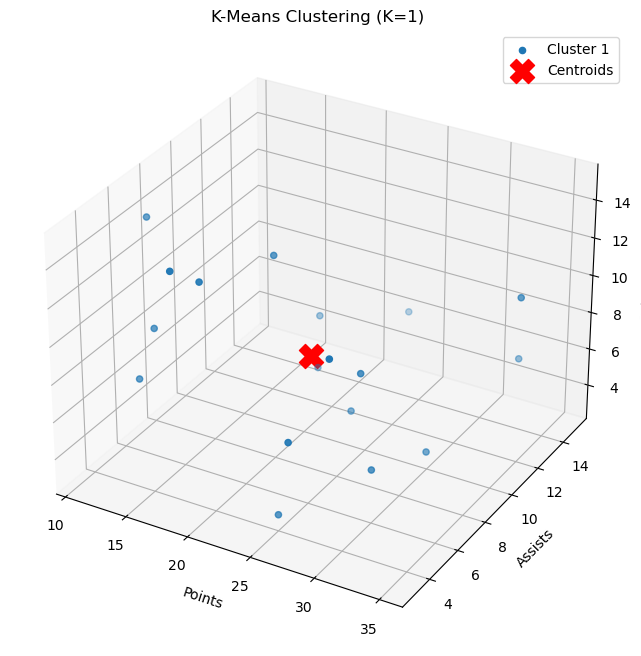

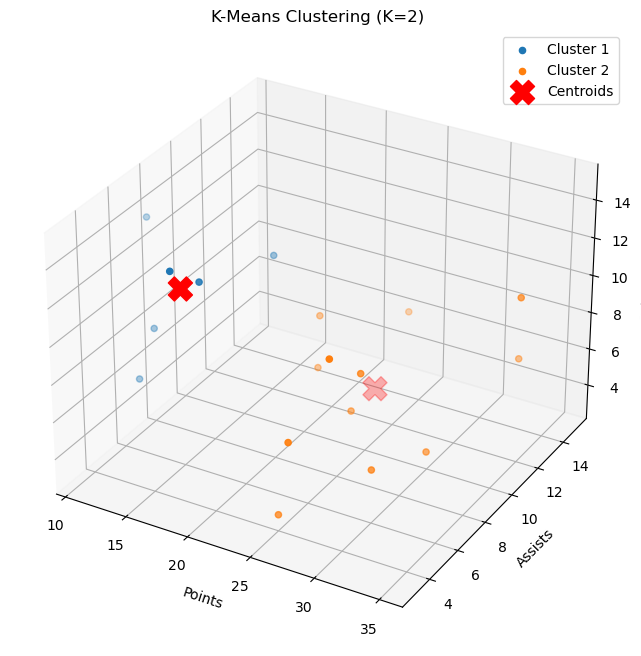

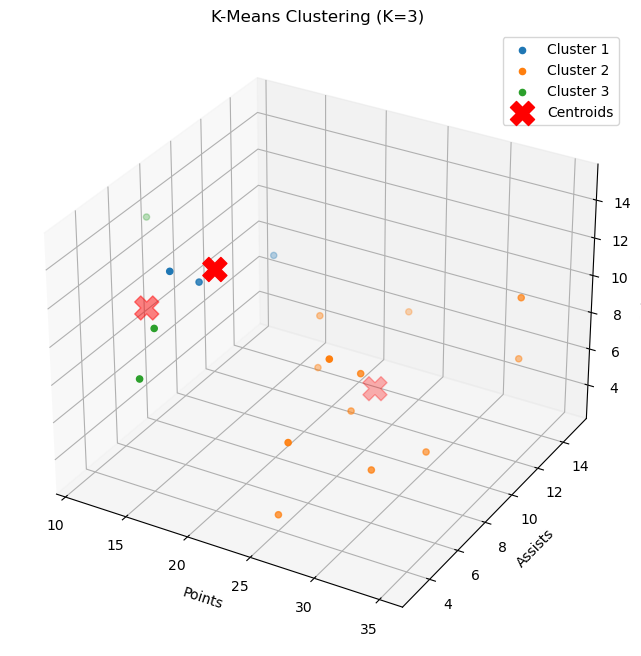

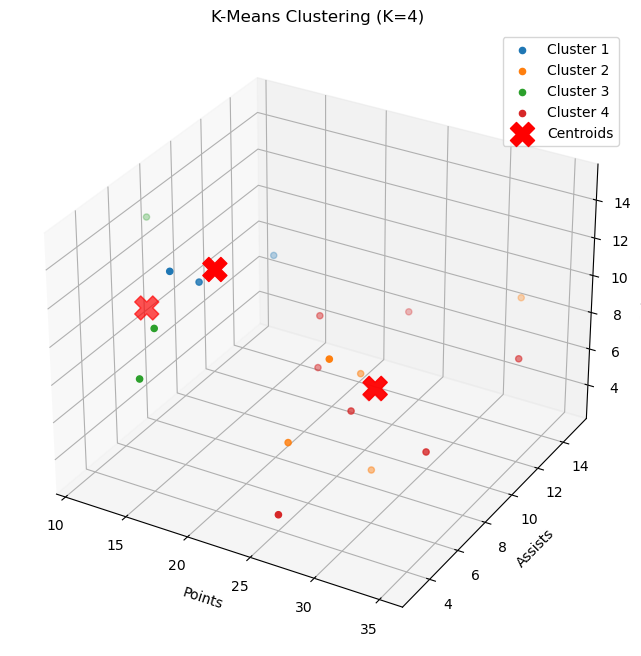

SSE for each K:
K=1, SSE=2980.45061728395
K=2, SSE=1488.1944444444446
K=3, SSE=1322.4722222222222
K=4, SSE=880.5910204081632


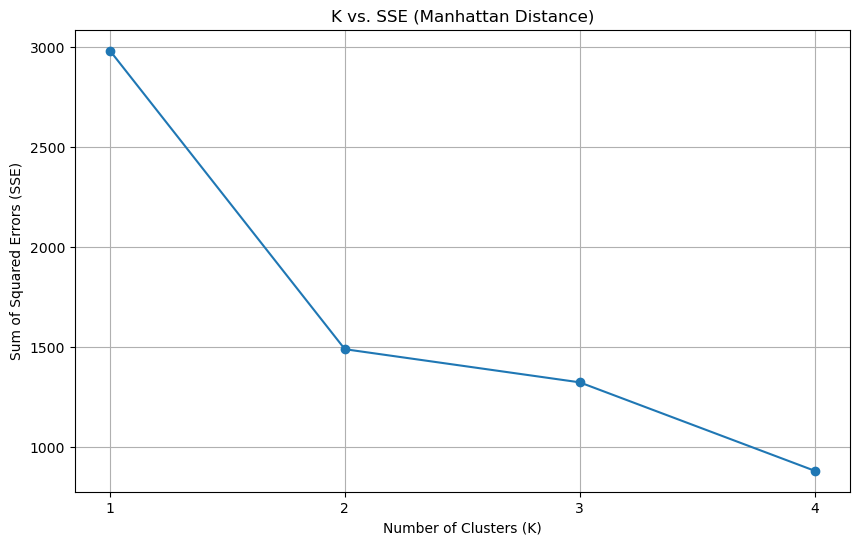

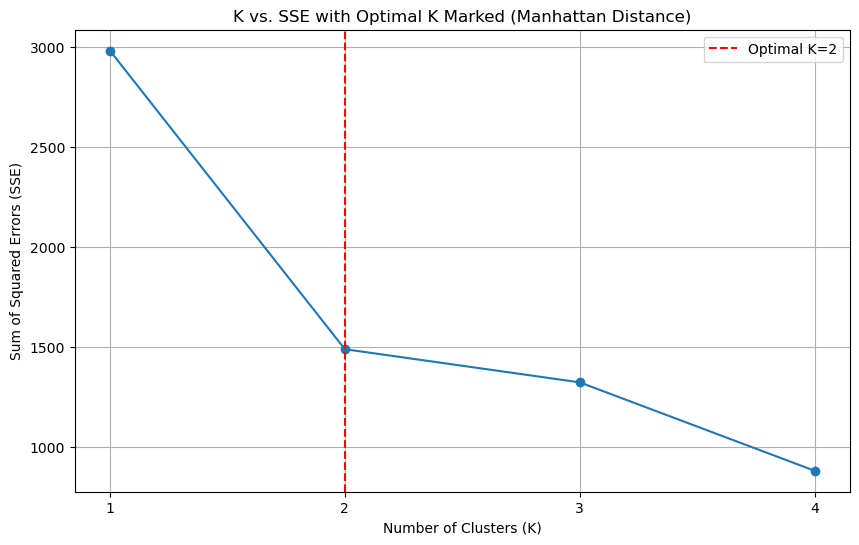

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Step 1: Create the DataFrame
data = {
    'points': [18.0, 19.0, 14.0, 14.0, 11.0, 20.0, 28.0, 30.0, 31.0, 35.0,
               33.0, 25.0, 25.0, 27.0, 29.0, 19.0, 23.0, 20.0],
    'assists': [3.0, 4.0, 5.0, 4.0, 7.0, 8.0, 7.0, 6.0, 9.0, 12.0,
                14.0, 9.0, 4.0, 3.0, 4.0, 12.0, 15.0, 11.0],
    'rebounds': [15, 14, 10, 8, 14, 13, 9, 5, 4, 11,
                 6, 5, 3, 8, 12, 7, 6, 5]
}

# Create a DataFrame
df = pd.DataFrame(data)

# Convert DataFrame to NumPy array
data_array = df.to_numpy()

# Step 2: K-means Clustering using Manhattan Distance
def manhattan_distance(a, b):
    return np.sum(np.abs(a - b))

def k_means_clustering(data, k, iterations=10):
    # Step 1: Initialize centroids
    if k == 1:
        centroids = np.mean(data, axis=0).reshape(1, -1)
    else:
        centroids = data[:k]

    for _ in range(iterations):
        # Step 2: Assign clusters
        distances = np.array([[manhattan_distance(point, centroid) for centroid in centroids] for point in data])
        clusters = np.argmin(distances, axis=1)

        # Step 3: Update centroids
        new_centroids = np.array([data[clusters == i].mean(axis=0) for i in range(k)])

        # Check for convergence (if centroids don't change)
        if np.all(centroids == new_centroids):
            break

        centroids = new_centroids

    return clusters, centroids

# Step 3: Visualizing the Data
def plot_data(data):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(data[:, 0], data[:, 1], data[:, 2], c='blue', marker='o')
    ax.set_title('Original Data Points')
    ax.set_xlabel('Points')
    ax.set_ylabel('Assists')
    ax.set_zlabel('Rebounds')
    plt.show()

def plot_clusters(data, clusters, centroids, k, title):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    for i in range(k):
        ax.scatter(data[clusters == i, 0], data[clusters == i, 1], data[clusters == i, 2], label=f'Cluster {i+1}')
    ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2], s=300, c='red', label='Centroids', marker='X')
    ax.set_title(title)
    ax.set_xlabel('Points')
    ax.set_ylabel('Assists')
    ax.set_zlabel('Rebounds')
    ax.legend()
    plt.show()

# Plot original data
plot_data(data_array)

# Step 4: Run K-means for Different Values of K and Calculate SSE
k_values = [1, 2, 3, 4]
sse_list = []

# Perform clustering for each K
for k in k_values:
    clusters, centroids = k_means_clustering(data_array, k)
    # Calculate SSE
    sse = np.sum([manhattan_distance(data_array[i], centroids[clusters[i]]) ** 2 for i in range(len(data_array))])
    sse_list.append(sse)
    plot_clusters(data_array, clusters, centroids, k, f'K-Means Clustering (K={k})')

# Display SSE results
print("SSE for each K:")
for k, sse in zip(k_values, sse_list):
    print(f'K={k}, SSE={sse}')

# Step 5: Plotting K vs. SSE
plt.figure(figsize=(10, 6))
plt.plot(k_values, sse_list, marker='o')
plt.title('K vs. SSE (Manhattan Distance)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.xticks(k_values)
plt.grid(True)
plt.show()

# Step 6: Determine the Optimal Value of K Using the Elbow Method
optimal_k = 2  # This is an example; determine it based on your SSE graph
plt.figure(figsize=(10, 6))
plt.plot(k_values, sse_list, marker='o')
plt.axvline(x=optimal_k, color='r', linestyle='--', label=f'Optimal K={optimal_k}')
plt.title('K vs. SSE with Optimal K Marked (Manhattan Distance)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.xticks(k_values)
plt.grid(True)
plt.legend()
plt.show()


QUESTION 3. Redo 1(a)-1(d) using Minkowski distance.

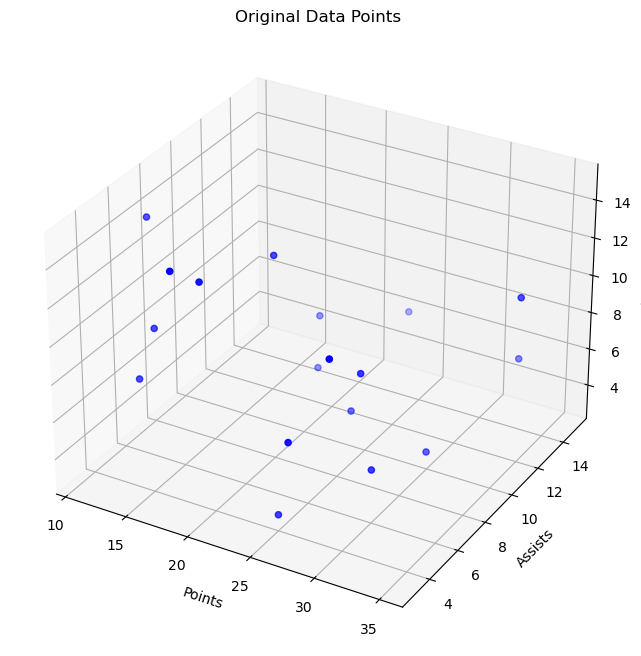

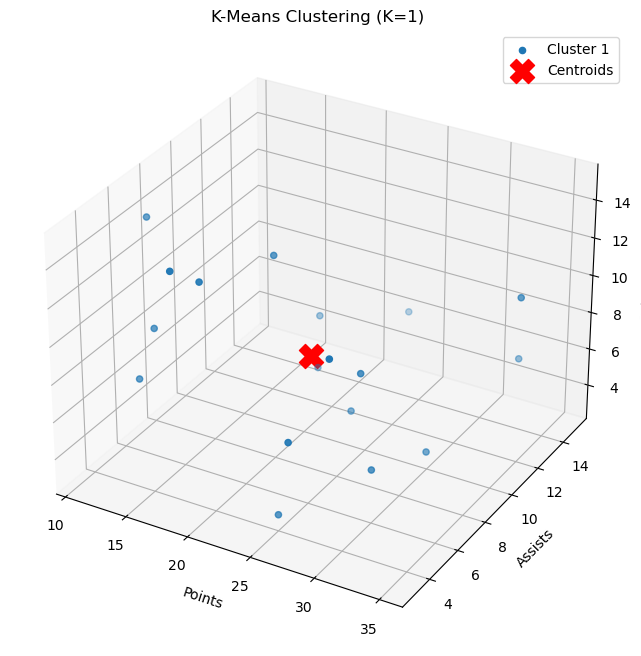

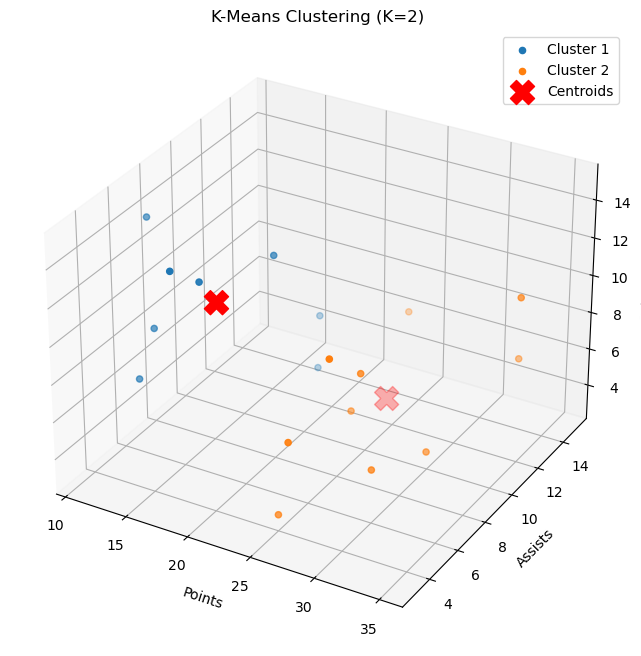

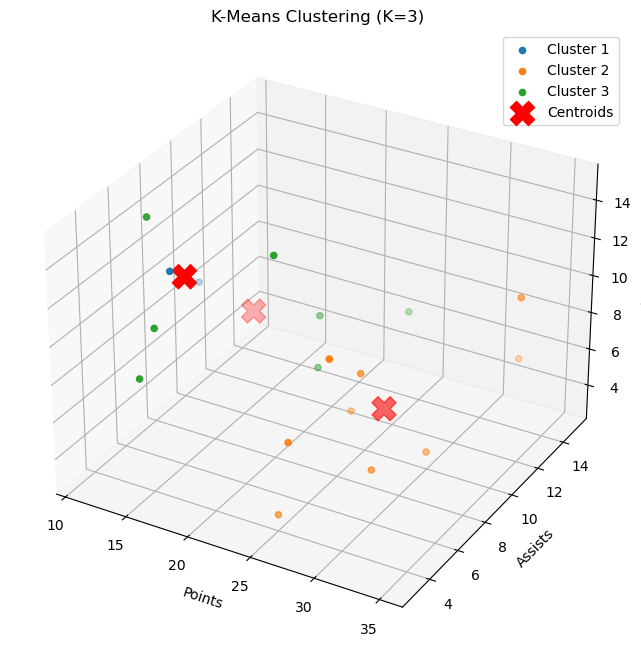

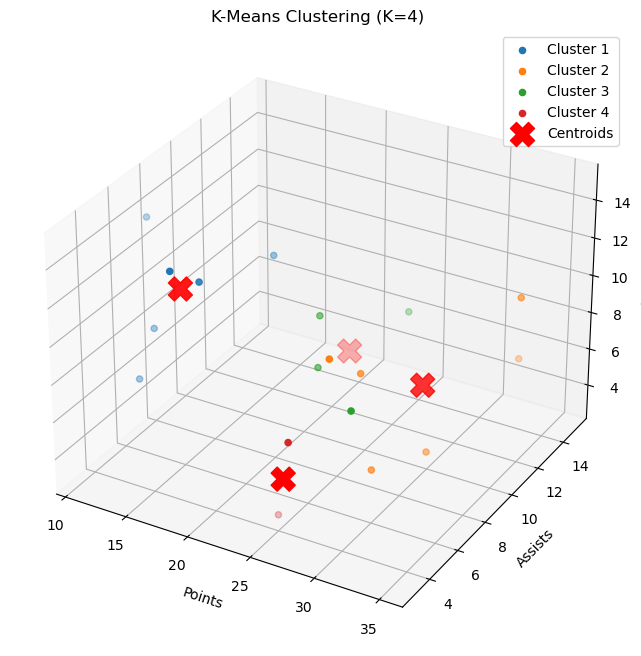

SSE for each K:
K=1, SSE=1095.7936522421587
K=2, SSE=489.0406065106791
K=3, SSE=435.24929320501343
K=4, SSE=270.89290294416446


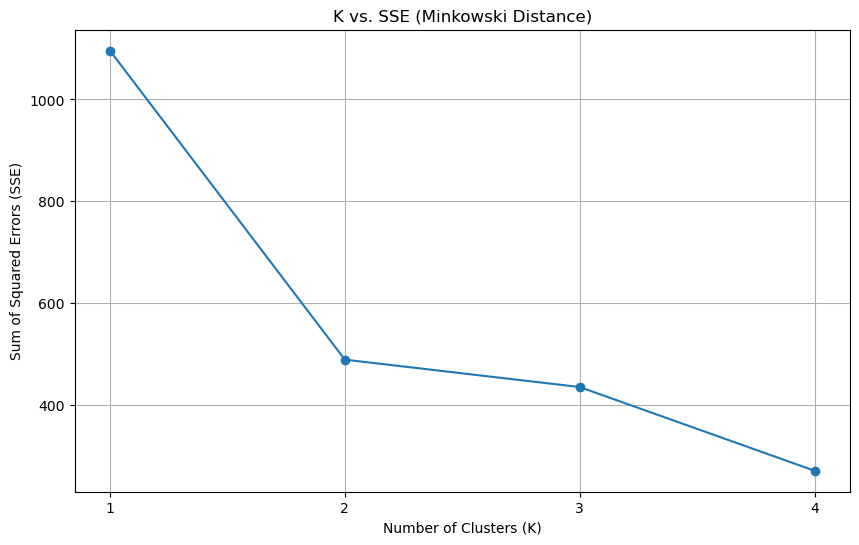

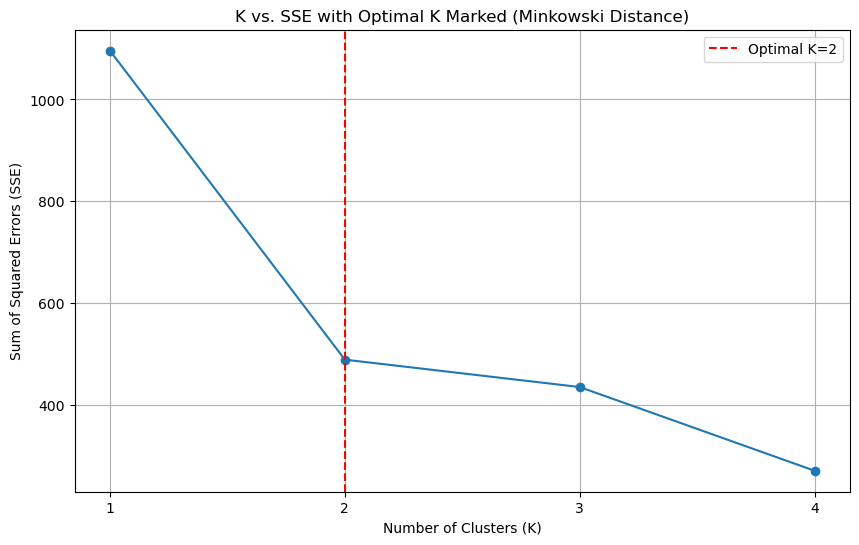

In [28]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Step 1: Create the DataFrame
data = {
    'points': [18.0, 19.0, 14.0, 14.0, 11.0, 20.0, 28.0, 30.0, 31.0, 35.0,
               33.0, 25.0, 25.0, 27.0, 29.0, 19.0, 23.0, 20.0],
    'assists': [3.0, 4.0, 5.0, 4.0, 7.0, 8.0, 7.0, 6.0, 9.0, 12.0,
                14.0, 9.0, 4.0, 3.0, 4.0, 12.0, 15.0, 11.0],
    'rebounds': [15, 14, 10, 8, 14, 13, 9, 5, 4, 11,
                 6, 5, 3, 8, 12, 7, 6, 5]
}

# Create a DataFrame
df = pd.DataFrame(data)

# Convert DataFrame to NumPy array
data_array = df.to_numpy()

# Step 2: K-means Clustering using Minkowski Distance
def minkowski_distance(a, b, p):
    return np.sum(np.abs(a - b) ** p) ** (1/p)

def k_means_clustering(data, k, p=3, iterations=10):
    # Step 1: Initialize centroids
    if k == 1:
        centroids = np.mean(data, axis=0).reshape(1, -1)
    else:
        centroids = data[:k]

    for _ in range(iterations):
        # Step 2: Assign clusters
        distances = np.array([[minkowski_distance(point, centroid, p) for centroid in centroids] for point in data])
        clusters = np.argmin(distances, axis=1)

        # Step 3: Update centroids
        new_centroids = np.array([data[clusters == i].mean(axis=0) for i in range(k)])

        # Check for convergence (if centroids don't change)
        if np.all(centroids == new_centroids):
            break

        centroids = new_centroids

    return clusters, centroids

# Step 3: Visualizing the Data
def plot_data(data):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(data[:, 0], data[:, 1], data[:, 2], c='blue', marker='o')
    ax.set_title('Original Data Points')
    ax.set_xlabel('Points')
    ax.set_ylabel('Assists')
    ax.set_zlabel('Rebounds')
    plt.show()

def plot_clusters(data, clusters, centroids, k, title):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    for i in range(k):
        ax.scatter(data[clusters == i, 0], data[clusters == i, 1], data[clusters == i, 2], label=f'Cluster {i+1}')
    ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2], s=300, c='red', label='Centroids', marker='X')
    ax.set_title(title)
    ax.set_xlabel('Points')
    ax.set_ylabel('Assists')
    ax.set_zlabel('Rebounds')
    ax.legend()
    plt.show()

# Plot original data
plot_data(data_array)

# Step 4: Run K-means for Different Values of K and Calculate SSE
k_values = [1, 2, 3, 4]
sse_list = []

# Perform clustering for each K
for k in k_values:
    clusters, centroids = k_means_clustering(data_array, k, p=3)  # Using p=3 for Minkowski distance
    # Calculate SSE
    sse = np.sum([minkowski_distance(data_array[i], centroids[clusters[i]], p=3) ** 2 for i in range(len(data_array))])
    sse_list.append(sse)
    plot_clusters(data_array, clusters, centroids, k, f'K-Means Clustering (K={k})')

# Display SSE results
print("SSE for each K:")
for k, sse in zip(k_values, sse_list):
    print(f'K={k}, SSE={sse}')

# Step 5: Plotting K vs. SSE
plt.figure(figsize=(10, 6))
plt.plot(k_values, sse_list, marker='o')
plt.title('K vs. SSE (Minkowski Distance)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.xticks(k_values)
plt.grid(True)
plt.show()

# Step 6: Determine the Optimal Value of K Using the Elbow Method
optimal_k = 2  # This is an example; determine it based on your SSE graph
plt.figure(figsize=(10, 6))
plt.plot(k_values, sse_list, marker='o')
plt.axvline(x=optimal_k, color='r', linestyle='--', label=f'Optimal K={optimal_k}')
plt.title('K vs. SSE with Optimal K Marked (Minkowski Distance)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.xticks(k_values)
plt.grid(True)
plt.legend()
plt.show()
